<a href="https://colab.research.google.com/github/ralralra/jetson_DLI/blob/main/%E1%84%8E%E1%85%AE%E1%86%BC%E1%84%82%E1%85%A1%E1%86%B7%E1%84%8C%E1%85%B5%E1%84%8B%E1%85%A7%E1%86%A8_%E1%84%83%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A5%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8_%E1%84%8C%E1%85%A5%E1%86%BC%E1%84%8E%E1%85%A2%E1%86%A8%EC%A0%9C%EC%95%88_%EC%99%84%EC%84%B1%ED%98%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 1: 데이터 이해하기


<img src = 'https://drive.google.com/uc?id=1fN1yEY_03NLscXKXQ2hMBJO9Zlc96cT1' width = '700'>

### 데이터 분석이란?
데이터 분석은 수집된 자료에서 규칙, 차이, 변화, 관계를 찾아내고 이를 바탕으로 합리적인 판단을 내리는 과정이다. 이 수업에서는 천안시 주민등록 인구 데이터를 활용하여 지역의 인구 변화와 세대 구조 변화를 살펴본다.

### 인구 데이터의 중요성
인구 데이터는 지역의 현재 상태와 미래 과제를 이해하는 기본 자료이다. 인구 변화는 학교, 교통, 복지, 주택, 상권, 청년 정책 등 다양한 지역 정책과 연결된다. 따라서 인구 데이터를 분석하면 지역문제를 감각이나 추측이 아니라 수치와 근거를 바탕으로 탐구할 수 있다.

### 천안시 인구 데이터 소개
이 노트북에서 사용하는 데이터는 행정안전부 주민등록 인구통계에서 제공하는 **월간 주민등록인구 및 세대현황 자료**이다. 파일명 예시는 `202101_202512_주민등록인구및세대현황_월간.csv`와 같다.

이 자료에는 다음 정보가 포함되어 있다.

- 행정구역별 주민등록 인구
- 월별 총인구수
- 세대수 및 세대당 인구
- 남자 인구수와 여자 인구수
- 남여 비율

> 주의: 주민등록 인구는 실제 생활인구나 유동인구가 아니라 주민등록상 주소지를 기준으로 집계된 자료이다. 따라서 통학, 통근, 관광, 상권 이용 인구까지 모두 설명하지는 못한다.


[인구데이터](https://jumin.mois.go.kr/#)

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
!pip install koreanize-matplotlib

#실행후 세션다시시작 하기
# 한글 폰트 설정 (그래프에 한글이 깨지지 않도록)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (41.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
plt.rc('font', family='NanumBarunGothic')
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 현상 해결

#폰트 설정하기

In [2]:
# 필요한 라이브러리 불러오기
import pandas as pd  #표데이터, 정형데이터, 반정형데이터
import numpy as np  #리스트를 다루는 라이브러리
import seaborn as sns  #그래프 그리는 라이브러리

In [3]:
# 그래프 저장을 위한 함수만들기
# 그래프가 생성될 때마다 save_plot('파일이름')을 실행하면 PNG 파일로 저장된다.
# 저장된 파일은 Colab 왼쪽 파일 탭의 output_graphs 폴더에서 확인할 수 있다.

import os
from datetime import datetime
import matplotlib.pyplot as plt

GRAPH_DIR = 'output_graphs'
os.makedirs(GRAPH_DIR, exist_ok=True)

def save_plot(filename, dpi=200):
    # 현재 화면에 그려진 matplotlib 그래프를 PNG 파일로 저장한다.
    safe_name = str(filename).replace('/', '_').replace(' ', '_')
    if not safe_name.endswith('.png'):
        safe_name += '.png'
    path = os.path.join(GRAPH_DIR, safe_name)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'그래프 저장 완료: {path}')



---

## 초기데이터 정리

In [4]:
# 로컬 파일 업로드
from google.colab import files
uploaded = files.upload()  # 파일 선택 창이 뜨면 파일 선택

Saving 2016_2025천안주민등록인구.csv to 2016_2025천안주민등록인구 (1).csv


In [5]:
# 파일명을 변수에 저장
file_name = list(uploaded.keys())[0]
print("업로드된 파일명:", file_name)

업로드된 파일명: 2016_2025천안주민등록인구 (1).csv


In [7]:
file_name = '/content/2016_2025천안주민등록인구.csv'

# CSV 파일 불러오기 (인코딩 문제 해결)
# 한글 CSV 파일은 주로 'cp949' 또는 'euc-kr' 인코딩을 사용
try:
    # 먼저 'cp949' 인코딩으로 시도
    df = pd.read_csv(file_name, encoding='cp949')
except:
    try:
        # 'cp49'가 실패하면 'euc-kr' 인코딩으로 시도
        df = pd.read_csv(file_name, encoding='euc-kr')
    except:
        # 위 인코딩이 모두 실패하면 'utf-8'로 시도
        df = pd.read_csv(file_name, encoding='utf-8')


In [8]:
print("데이터 크기:", df.shape)  # 행과 열의 개수

데이터 크기: (35, 61)


In [9]:
df.head()  # 상위 5개 행 출력

,행정구역,2016년_거주자 인구수,2016년_세대수,2016년_세대당 인구,2016년_남자 인구수,2016년_여자 인구수,2016년_남여 비율,2017년_거주자 인구수,2017년_세대수,2017년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,충청남도 충청남도 천안시 (4413000000),"614,024","251,244",2.44,"311,800","302,224",1.03,"627,608","260,015",2.41,...,2.12,"336,946","320,468",1.05,"661,893","315,892",2.10,"339,175","322,718",1.05
1,충청남도 충청남도 천안시 동남구 (4413100000),"256,940","105,757",2.43,"129,971","126,969",1.02,"253,905","106,373",2.39,...,2.09,"131,854","128,307",1.03,"261,460","126,728",2.06,"132,354","129,106",1.03
2,충청남도 천안시 동남구 목천읍(4413125000),"26,499","10,751",2.46,"13,543","12,956",1.05,"26,051","10,755",2.42,...,2.02,"11,486","10,899",1.05,"21,843","11,079",1.97,"11,197","10,646",1.05
3,충청남도 천안시 동남구 풍세면(4413131000),"4,394","2,051",2.14,"2,339","2,055",1.14,"4,294","2,041",2.10,...,1.93,"5,226","4,717",1.11,"10,608","5,433",1.95,"5,587","5,021",1.11
4,충청남도 천안시 동남구 광덕면(4413132000),"4,502","2,222",2.03,"2,279","2,223",1.03,"4,487","2,239",2.00,...,1.78,"2,046","1,994",1.03,"3,937","2,249",1.75,"1,979","1,958",1.01


In [10]:
# 데이터프레임에서 천안시 행을 삭제.
df = df.drop(0) #0번째 행을 삭제
df.head()

,행정구역,2016년_거주자 인구수,2016년_세대수,2016년_세대당 인구,2016년_남자 인구수,2016년_여자 인구수,2016년_남여 비율,2017년_거주자 인구수,2017년_세대수,2017년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
1,충청남도 충청남도 천안시 동남구 (4413100000),"256,940","105,757",2.43,"129,971","126,969",1.02,"253,905","106,373",2.39,...,2.09,"131,854","128,307",1.03,"261,460","126,728",2.06,"132,354","129,106",1.03
2,충청남도 천안시 동남구 목천읍(4413125000),"26,499","10,751",2.46,"13,543","12,956",1.05,"26,051","10,755",2.42,...,2.02,"11,486","10,899",1.05,"21,843","11,079",1.97,"11,197","10,646",1.05
3,충청남도 천안시 동남구 풍세면(4413131000),"4,394","2,051",2.14,"2,339","2,055",1.14,"4,294","2,041",2.10,...,1.93,"5,226","4,717",1.11,"10,608","5,433",1.95,"5,587","5,021",1.11
4,충청남도 천안시 동남구 광덕면(4413132000),"4,502","2,222",2.03,"2,279","2,223",1.03,"4,487","2,239",2.00,...,1.78,"2,046","1,994",1.03,"3,937","2,249",1.75,"1,979","1,958",1.01
5,충청남도 천안시 동남구 북면(4413133000),"4,737","2,395",1.98,"2,455","2,282",1.08,"4,645","2,379",1.95,...,1.70,"2,186","1,991",1.10,"4,020","2,390",1.68,"2,092","1,928",1.09


In [11]:
# 데이터프레임에서 동남구 행을 삭제.
df = df.drop(1) #index1번삭제
df

,행정구역,2016년_거주자 인구수,2016년_세대수,2016년_세대당 인구,2016년_남자 인구수,2016년_여자 인구수,2016년_남여 비율,2017년_거주자 인구수,2017년_세대수,2017년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
2,충청남도 천안시 동남구 목천읍(4413125000),"26,499","10,751",2.46,"13,543","12,956",1.05,"26,051","10,755",2.42,...,2.02,"11,486","10,899",1.05,"21,843","11,079",1.97,"11,197","10,646",1.05
3,충청남도 천안시 동남구 풍세면(4413131000),"4,394","2,051",2.14,"2,339","2,055",1.14,"4,294","2,041",2.10,...,1.93,"5,226","4,717",1.11,"10,608","5,433",1.95,"5,587","5,021",1.11
4,충청남도 천안시 동남구 광덕면(4413132000),"4,502","2,222",2.03,"2,279","2,223",1.03,"4,487","2,239",2.00,...,1.78,"2,046","1,994",1.03,"3,937","2,249",1.75,"1,979","1,958",1.01
5,충청남도 천안시 동남구 북면(4413133000),"4,737","2,395",1.98,"2,455","2,282",1.08,"4,645","2,379",1.95,...,1.70,"2,186","1,991",1.10,"4,020","2,390",1.68,"2,092","1,928",1.09
6,충청남도 천안시 동남구 성남면(4413134000),"3,552","1,656",2.14,"1,861","1,691",1.10,"3,493","1,669",2.09,...,1.86,"1,505","1,353",1.11,"2,764","1,537",1.80,"1,468","1,296",1.13
7,충청남도 천안시 동남구 수신면(4413135000),"2,466","1,213",2.03,"1,312","1,154",1.14,"2,422","1,234",1.96,...,1.66,"1,166",929,1.26,"2,031","1,233",1.65,"1,139",892,1.28
8,충청남도 천안시 동남구 병천면(4413136000),"6,470","3,215",2.01,"3,360","3,110",1.08,"6,444","3,287",1.96,...,1.66,"3,285","2,734",1.20,"5,839","3,580",1.63,"3,188","2,651",1.20
9,충청남도 천안시 동남구 동면(4413137000),"2,265","1,123",2.02,"1,184","1,081",1.10,"2,233","1,153",1.94,...,1.70,"1,047",871,1.20,"1,890","1,126",1.68,"1,033",857,1.21
10,충청남도 천안시 동남구 중앙동(4413151000),"5,597","3,024",1.85,"2,974","2,623",1.13,"5,528","3,004",1.84,...,1.66,"2,441","2,281",1.07,"4,474","2,759",1.62,"2,341","2,133",1.10
11,충청남도 천안시 동남구 문성동(4413152000),"4,470","2,541",1.76,"2,368","2,102",1.13,"4,180","2,421",1.73,...,2.05,"3,934","3,833",1.03,"7,742","3,847",2.01,"3,912","3,830",1.02


In [12]:
# 데이터프레임에서 서북구 행을 삭제.
df = df.drop(19)
df

,행정구역,2016년_거주자 인구수,2016년_세대수,2016년_세대당 인구,2016년_남자 인구수,2016년_여자 인구수,2016년_남여 비율,2017년_거주자 인구수,2017년_세대수,2017년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
2,충청남도 천안시 동남구 목천읍(4413125000),"26,499","10,751",2.46,"13,543","12,956",1.05,"26,051","10,755",2.42,...,2.02,"11,486","10,899",1.05,"21,843","11,079",1.97,"11,197","10,646",1.05
3,충청남도 천안시 동남구 풍세면(4413131000),"4,394","2,051",2.14,"2,339","2,055",1.14,"4,294","2,041",2.10,...,1.93,"5,226","4,717",1.11,"10,608","5,433",1.95,"5,587","5,021",1.11
4,충청남도 천안시 동남구 광덕면(4413132000),"4,502","2,222",2.03,"2,279","2,223",1.03,"4,487","2,239",2.00,...,1.78,"2,046","1,994",1.03,"3,937","2,249",1.75,"1,979","1,958",1.01
5,충청남도 천안시 동남구 북면(4413133000),"4,737","2,395",1.98,"2,455","2,282",1.08,"4,645","2,379",1.95,...,1.70,"2,186","1,991",1.10,"4,020","2,390",1.68,"2,092","1,928",1.09
6,충청남도 천안시 동남구 성남면(4413134000),"3,552","1,656",2.14,"1,861","1,691",1.10,"3,493","1,669",2.09,...,1.86,"1,505","1,353",1.11,"2,764","1,537",1.80,"1,468","1,296",1.13
7,충청남도 천안시 동남구 수신면(4413135000),"2,466","1,213",2.03,"1,312","1,154",1.14,"2,422","1,234",1.96,...,1.66,"1,166",929,1.26,"2,031","1,233",1.65,"1,139",892,1.28
8,충청남도 천안시 동남구 병천면(4413136000),"6,470","3,215",2.01,"3,360","3,110",1.08,"6,444","3,287",1.96,...,1.66,"3,285","2,734",1.20,"5,839","3,580",1.63,"3,188","2,651",1.20
9,충청남도 천안시 동남구 동면(4413137000),"2,265","1,123",2.02,"1,184","1,081",1.10,"2,233","1,153",1.94,...,1.70,"1,047",871,1.20,"1,890","1,126",1.68,"1,033",857,1.21
10,충청남도 천안시 동남구 중앙동(4413151000),"5,597","3,024",1.85,"2,974","2,623",1.13,"5,528","3,004",1.84,...,1.66,"2,441","2,281",1.07,"4,474","2,759",1.62,"2,341","2,133",1.10
11,충청남도 천안시 동남구 문성동(4413152000),"4,470","2,541",1.76,"2,368","2,102",1.13,"4,180","2,421",1.73,...,2.05,"3,934","3,833",1.03,"7,742","3,847",2.01,"3,912","3,830",1.02


In [13]:
# 중복된 인구 정래 되었으니 수치형 데이터의 기술 통계량 확인
df.describe()

,2016년_세대당 인구,2016년_남여 비율,2017년_세대당 인구,2017년_남여 비율,2018년_세대당 인구,2018년_남여 비율,2019년_세대당 인구,2019년_남여 비율,2020년_세대당 인구,2020년_남여 비율,2021년_세대당 인구,2021년_남여 비율,2022년_세대당 인구,2022년_남여 비율,2023년_세대당 인구,2023년_남여 비율,2024년_세대당 인구,2024년_남여 비율,2025년_세대당 인구,2025년_남여 비율
count,32.000000,32.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2.174688,0.990312,2.276667,1.059333,2.228333,1.063667,2.184000,1.067333,2.124667,1.069667,2.091935,1.071935,2.066452,1.075161,2.037742,1.080000,2.012258,1.077419,1.984194,1.078710
std,0.673857,0.265822,0.369448,0.060965,0.354567,0.062172,0.348094,0.067514,0.345999,0.071991,0.344833,0.077821,0.331215,0.083541,0.324373,0.091177,0.311937,0.088806,0.309115,0.094648
min,0.000000,0.000000,1.670000,0.940000,1.610000,0.940000,1.570000,0.940000,1.510000,0.940000,1.480000,0.940000,1.450000,0.930000,1.430000,0.940000,1.410000,0.930000,1.390000,0.930000
25%,2.027500,0.997500,1.985000,1.002500,1.940000,1.012500,1.912500,1.012500,1.842500,1.012500,1.825000,1.010000,1.830000,1.005000,1.815000,1.010000,1.805000,1.010000,1.785000,1.010000
50%,2.195000,1.050000,2.170000,1.060000,2.140000,1.075000,2.120000,1.075000,2.075000,1.070000,2.020000,1.070000,2.010000,1.060000,1.990000,1.070000,1.950000,1.070000,1.950000,1.060000
75%,2.475000,1.092500,2.450000,1.097500,2.415000,1.097500,2.397500,1.107500,2.357500,1.110000,2.325000,1.115000,2.280000,1.120000,2.235000,1.125000,2.195000,1.125000,2.155000,1.125000
max,3.120000,1.160000,3.060000,1.170000,2.970000,1.200000,2.920000,1.200000,2.860000,1.200000,2.780000,1.230000,2.730000,1.220000,2.700000,1.260000,2.670000,1.260000,2.640000,1.280000


* 개수(count)
* 평균(mean)
* 표준편차(std)
* 최솟값(min)
* 25% 분위수(25th percentile)
* 50% 분위수(median)
* 75% 분위수(75th percentile)
* 최댓값(max)

In [19]:
df.head(3)

,행정구역,2016년_거주자 인구수,2016년_세대수,2016년_세대당 인구,2016년_남자 인구수,2016년_여자 인구수,2016년_남여 비율,2017년_거주자 인구수,2017년_세대수,2017년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
2,충청남도 천안시 동남구 목천읍(4413125000),"26,499","10,751",2.46,"13,543","12,956",1.05,"26,051","10,755",2.42,...,2.02,"11,486","10,899",1.05,"21,843","11,079",1.97,"11,197","10,646",1.05
3,충청남도 천안시 동남구 풍세면(4413131000),"4,394","2,051",2.14,"2,339","2,055",1.14,"4,294","2,041",2.10,...,1.93,"5,226","4,717",1.11,"10,608","5,433",1.95,"5,587","5,021",1.11
4,충청남도 천안시 동남구 광덕면(4413132000),"4,502","2,222",2.03,"2,279","2,223",1.03,"4,487","2,239",2.00,...,1.78,"2,046","1,994",1.03,"3,937","2,249",1.75,"1,979","1,958",1.01


In [14]:
# 행정구역 목록 확인
print("행정구역 목록:")
print(df['행정구역'].unique())

#unique 중복제외한 데이터 출력

행정구역 목록:
['충청남도 천안시 동남구 목천읍(4413125000)' '충청남도 천안시 동남구 풍세면(4413131000)'
 '충청남도 천안시 동남구 광덕면(4413132000)' '충청남도 천안시 동남구 북면(4413133000)'
 '충청남도 천안시 동남구 성남면(4413134000)' '충청남도 천안시 동남구 수신면(4413135000)'
 '충청남도 천안시 동남구 병천면(4413136000)' '충청남도 천안시 동남구 동면(4413137000)'
 '충청남도 천안시 동남구 중앙동(4413151000)' '충청남도 천안시 동남구 문성동(4413152000)'
 '충청남도 천안시 동남구 원성1동(4413153000)' '충청남도 천안시 동남구 원성2동(4413154000)'
 '충청남도 천안시 동남구 봉명동(4413155000)' '충청남도 천안시 동남구 일봉동(4413156000)'
 '충청남도 천안시 동남구 신방동(4413157000)' '충청남도 천안시 동남구 청룡동(4413158000)'
 '충청남도 천안시 동남구 신안동(4413159000)' '충청남도 천안시 서북구 성환읍(4413325000)'
 '충청남도 천안시 서북구 성거읍(4413325300)' '충청남도 천안시 서북구 직산읍(4413325600)'
 '충청남도 천안시 서북구 입장면(4413331000)' '충청남도 천안시 서북구 성정1동(4413351000)'
 '충청남도 천안시 서북구 성정2동(4413352000)' '충청남도 천안시 서북구 쌍용1동(4413353000)'
 '충청남도 천안시 서북구 쌍용2동(4413354000)' '충청남도 천안시 서북구 쌍용3동(4413355000)'
 '충청남도 천안시 서북구 백석동(4413356000)' '충청남도 천안시 서북구 불당동(4413356500)'
 '충청남도 천안시 서북구 불당1동(4413356600)' '충청남도 천안시 서북구 불당2동(4413356700)'
 '충청남도 천안시 서북구 부성1동(4413358000)' '충청남도 

``unique()``  - '행정구역' 컬럼에 있는 고유한 값들, 즉 중복되지 않는 모든 행정구역 목록을 출력

## 데이터 재구성 및 분석 준비



### 1. 왜 데이터를 재구성해야 할까?
원본 CSV 파일은 월별 항목이 각각 별도의 열로 들어 있는 **Wide 형식**이다.

예시:

`행정구역 | 2021년01월_총인구수 | 2021년01월_세대수 | ... | 2025년12월_총인구수 | 2025년12월_세대수`

이 구조는 한눈에 보기에는 편하지만, 연도별 변화 그래프를 그리거나 `groupby()`로 집계하기에는 불편하다. 따라서 분석하기 쉬운 **Long 형식**으로 바꾼다.

변환 후 구조:

`행정구역 | 연도 | 기준월 | 총인구수 | 세대수 | 세대당인구 | 남자인구수 | 여자인구수 | 남여비율`

### 2. 연도별 대표값은 무엇을 사용할까?
월간 데이터를 연도별로 비교하려면 기준을 정해야 한다. 이 수업에서는 **각 연도의 12월 값**을 그해의 대표값으로 사용한다.

- 12월 값: 연말 기준 인구를 비교하기에 적합하다.
- 연평균 값: 한 해 동안의 평균 상태를 볼 때 적합하다.

본 프로젝트의 목적은 연도별 변화를 직관적으로 비교하는 것이므로, 기본값은 **12월 기준**으로 설정한다.

> 단, 데이터에 12월 컬럼이 없으면 해당 연도의 가장 마지막 월을 자동으로 사용한다.


`replace(',', '')`: 숫자 안에 포함된 쉼표(,)를 제거합니다. 예를 들어, '1,234'와 같은 문자열이 있을 때, 쉼표를 제거하여 '1234'로 만듭니다. 쉼표는 숫자로 직접 변환할 때 오류를 일으킬 수 있기 때문에 제거합니다.

`.strip()`: 문자열의 양쪽 끝에 있는 공백(띄어쓰기, 탭, 줄 바꿈 등)을 제거합니다. 예를 들어, ' 1234 '는 '1234'가 됩니다. 불필요한 공백도 숫자 변환 시 오류를 유발할 수 있어 정리합니다.

`errors='coerce'`: 이 부분은 pd.to_numeric 함수에서 사용되는 중요한 옵션입니다. 만약 변환하려는 값이 숫자로 바뀔 수 없는 경우(예: 'abc' 같은 문자열), 보통은 오류가 발생하여 프로그램이 멈춥니다. 하지만 errors='coerce'를 사용하면, 이러한 오류 대신 해당 값을 NaN (Not a Number, 즉 숫자가 아님)으로 변환하여 프로그램이 계속 실행될 수 있도록 합니다. 이는 데이터에 예상치 못한 비수치 값이 있을 때 유용하게 사용됩니다.

### 1. 필요한 라이브러리 임포트

먼저 데이터 처리에 필요한 `re` (정규표현식), `pandas` (데이터프레임), `numpy` (수치 계산) 라이브러리를 임포트합니다.

In [15]:
import re
import pandas as pd
import numpy as np

### 2. `to_number` 함수 정의

이 함수는 CSV 파일에서 숫자를 읽을 때 발생할 수 있는 쉼표(`,`) 제거 및 공백 제거, 그리고 숫자로 변환할 수 없는 값(`NaN`) 처리 로직을 정의합니다. `errors='coerce'`를 사용하여 변환 불가능한 값은 `NaN`으로 만듭니다.

In [16]:
# 숫자 변환 함수: '1,234'처럼 쉼표가 포함된 문자열을 숫자로 바꾼다.
def to_number(value):
    if pd.isna(value):
        return np.nan
    return pd.to_numeric(str(value).replace(',', '').strip(), errors='coerce')

### 3. `extract_year_month` 함수 정의

이 함수는 컬럼명에서 연도와 월 정보를 추출합니다. 컬럼명에 'YYYY년MM월' 패턴이 있으면 연도와 월을 추출하고, 'YYYY년' 패턴만 있으면 12월을 기본값으로 할당합니다. 이렇게 함으로써 연간 데이터와 월간 데이터를 모두 처리할 수 있습니다.

In [17]:
# 컬럼명에서 연도와 월을 추출하는 함수
# 예: '2025년12월_거주자 인구수' → (2025, 12)
# '2025년_거주자 인구수' → (2025, 12) (월이 없으면 12월로 간주)
def extract_year_month(column_name):
    # Try to find 'YYYY년MM월' pattern
    month_match = re.search(r'(20\d{2})년\s*(\d{1,2})월', column_name)
    if month_match:
        return int(month_match.group(1)), int(month_match.group(2))
    # If not found, try to find 'YYYY년' pattern and assume 12th month
    year_match = re.search(r'(20\d{2})년', column_name)
    if year_match:
        return int(year_match.group(1)), 12 # Default to 12 for yearly columns
    return None, None

### 4. 분석 대상 연도 확인

`extract_year_month` 함수를 사용하여 원본 데이터프레임 `df`의 컬럼명에서 모든 연도 정보를 추출하고, 중복을 제거한 후 정렬하여 `available_years` 리스트를 만듭니다. 이 리스트는 데이터 재구성 과정에서 어떤 연도들을 처리할지 결정하는 기준이 됩니다.

In [18]:
# 분석 대상 연도 확인
available_years = sorted({extract_year_month(c)[0] for c in df.columns if extract_year_month(c)[0] is not None})
print('데이터에 포함된 연도:', available_years)

데이터에 포함된 연도: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### 5. 빈 리스트 및 지표 키워드 정의

`long_data`는 재구성된 데이터를 담을 리스트이며, `missing_log`는 데이터 처리 중 누락된 지표를 기록할 리스트입니다.

`metric_keywords` 딕셔너리는 `long_df`에 생성될 지표 컬럼명(예: '총인구수')과 원본 `df` 컬럼명에 포함될 키워드(예: '거주자 인구수')를 매핑합니다. 이를 통해 원본 데이터의 다양한 컬럼명으로부터 원하는 지표를 유연하게 추출할 수 있습니다.

In [19]:
long_data = []
missing_log = []

# 사용할 지표와 원본 컬럼명에 들어 있는 키워드
metric_keywords = {
    '총인구수': ['거주자 인구수'],
    '세대수': ['세대수'],
    '세대당인구': ['세대당 인구'],
    '남자인구수': ['남자 인구수'],
    '여자인구수': ['여자 인구수'],
    '남여비율': ['남여 비율']
}

### 6. 데이터 재구성 루프

이 부분은 `df`의 각 행(행정구역)과 각 ***`available_years`에 대해 반복하면서 'Wide' 형식의 데이터를 'Long' 형식으로 변환하는 핵심 로직입니다.***

*   **`base_month` 결정**: 해당 연도의 12월 데이터가 있으면 12월을 사용하고, 없으면 해당 연도의 마지막 월을 사용합니다. 이는 연도별 대표값을 선정하는 기준이 됩니다.
*   **`record` 생성**: 각 행정구역, 연도, 기준월별로 `record` 딕셔너리를 생성합니다.
*   **지표 값 추출**: `metric_keywords`를 사용하여 '총인구수', '세대수' 등 각 지표에 해당하는 값을 원본 `df`에서 찾아 `to_number` 함수로 변환하여 `record`에 추가합니다. 데이터가 없는 경우 `missing_log`에 기록합니다.
*   **`long_data`에 추가**: 완성된 `record`를 `long_data` 리스트에 추가합니다.

In [20]:
for _, row in df.iterrows():
    region = row['행정구역']

    for year in available_years:
        # 해당 연도의 컬럼 중 월 정보가 있는 컬럼만 추출
        year_columns = [c for c in df.columns if extract_year_month(c)[0] == year]
        months = sorted({extract_year_month(c)[1] for c in year_columns if extract_year_month(c)[1] is not None})
        if not months:
            # If no months found, default to 12 as per the new extract_year_month logic
            base_month = 12
        else:
            # 12월이 있으면 12월, 없으면 가장 마지막 월 사용
            base_month = 12 if 12 in months else max(months)

        record = {
            '행정구역': region,
            '연도': year,
            '기준월': base_month
        }

        ok = True
        for metric, keywords in metric_keywords.items():
            candidates = []
            for c in year_columns:
                y, m = extract_year_month(c)
                if m == base_month and any(k in c for k in keywords):
                    candidates.append(c)
            if candidates:
                record[metric] = to_number(row[candidates[0]])
            else:
                record[metric] = np.nan
                missing_log.append((region, year, base_month, metric))
                ok = False

        long_data.append(record)

### 7. `long_df` 데이터프레임 생성 및 파생 지표 재계산

`long_data` 리스트를 이용하여 최종 `long_df` 데이터프레임을 생성합니다.

또한, `세대당인구`와 `남여비율`은 원본 데이터에 값이 존재하더라도 일관된 기준을 유지하고 정확성을 높이기 위해 `총인구수`, `세대수`, `남자인구수`, `여자인구수`를 기반으로 다시 계산합니다.

In [21]:
long_df = pd.DataFrame(long_data)

# 공식 통일: 세대당인구와 남여비율은 원본값이 있어도 다시 계산한다.
# 이유: 지역별 합계나 추후 집계에서 일관된 기준을 유지하기 위해서이다.
long_df['세대당인구'] = long_df['총인구수'] / long_df['세대수']
long_df['남여비율'] = long_df['남자인구수'] / long_df['여자인구수'] * 100

### 8. 재구성 결과 확인

재구성된 `long_df`의 크기와 누락된 지표 여부를 확인합니다. 마지막으로 `long_df`의 상위 5개 행을 출력하여 데이터가 올바르게 재구성되었는지 최종적으로 점검합니다.

In [22]:
print('데이터 재구성 완료')
print('Long 형식 데이터 크기:', long_df.shape)

if missing_log:
    print(f'주의: 일부 지표가 누락된 경우가 {len(missing_log)}건 있습니다. 앞의 10건만 표시합니다.')
    print(missing_log[:10])

long_df.head()

데이터 재구성 완료
Long 형식 데이터 크기: (320, 9)


,행정구역,연도,기준월,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
0,충청남도 천안시 동남구 목천읍(4413125000),2016,12,26499.0,10751.0,2.464794,13543.0,12956.0,104.530719
1,충청남도 천안시 동남구 목천읍(4413125000),2017,12,26051.0,10755.0,2.422222,13324.0,12727.0,104.690815
2,충청남도 천안시 동남구 목천읍(4413125000),2018,12,24802.0,10523.0,2.356932,12692.0,12110.0,104.805945
3,충청남도 천안시 동남구 목천읍(4413125000),2019,12,24134.0,10545.0,2.288668,12376.0,11758.0,105.255996
4,충청남도 천안시 동남구 목천읍(4413125000),2020,12,24129.0,10926.0,2.208402,12326.0,11803.0,104.431077




---



# 데이터 분석하기: 천안시 인구 변화와 지역문제 탐구

## 이 단계의 수업 목표

이 과정은 고등학생이 지역 데이터를 활용하여 문제를 발견하고, 분석 결과를 바탕으로 추가 질문과 정책 아이디어를 제안하는 프로젝트이다. 따라서 복잡한 알고리즘을 많이 사용하는 것보다, **계산한 지표의 의미와 해석 가능 범위**를 정확히 이해하는 것이 중요하다.

## 분석 질문

1. 천안시 전체 인구는 증가, 정체, 감소 중 어느 흐름에 가까울까?
2. 인구 변화와 세대수 변화는 같은 방향으로 움직일까?
3. 세대당 인구 변화는 지역 생활 구조에 대해 어떤 질문이 떠오를까?
4. 읍·면·동별 변화는 서로 어떻게 다를까?
5. 비슷한 특성을 가진 지역을 묶어보면 어떤 유형이 나타나는가?
6. 현재 데이터만으로 말할 수 있는 것과, 추가 데이터가 있어야 말할 수 있는 것은 무엇일까?

## 분석 알고리즘 사용 원칙

본 프로젝트에서 사용하는 분석 방법은 **핵심 분석**과 **심화 분석**으로 구분한다.

| 구분 | 분석 방법 | 수업 내 역할 | 적절성 | 주의점 |
|---|---|---|---|---|
| 핵심 분석 | 기초 통계, 집계, 비율 계산 | 데이터의 전체 흐름 파악 | 매우 적절 | 공식의 의미를 설명해야 함 |
| 핵심 분석 | 전년 대비 증감률, 기간 변화율 | 변화의 방향과 속도 파악 | 적절 | 작은 지역은 변화율이 과장될 수 있음 |
| 핵심 분석 | 시각화 | 변화와 차이를 직관적으로 표현 | 매우 적절 | 그래프만 보고 원인을 단정하지 않음 |
| 심화 분석 | K-Means 클러스터링 | 비슷한 지역 유형 탐색 | 조건부 적절 | 고령화·청년 유출을 직접 설명하지 못함 |
| 심화 분석 | 미래 인구 시나리오 | 가정에 따른 변화 가능성 탐색 | 조건부 적절 | 개인적 시나리오로 진행된 시뮬레이션임 |

따라서 이 노트북은 다음 순서로 진행한다.

`데이터 확인 → 연도별 집계 → 비율 계산 → 증감률 분석 → 시각화 → 지역별 비교 → 심화 분석 → 정책 제안`

## 1. 데이터 최종 점검

분석하기 전에 데이터 기간, 행정구역 수, 기준월을 확인한다. 데이터 분석에서는 계산보다 먼저 **내가 어떤 자료를 기준으로 말하고 있는지** 확인해야 한다.

본 자료는 월간 주민등록 인구 데이터를 사용한다. 월간 데이터를 연도별로 비교하려면 기준월을 정해야 한다. 이 수업에서는 **각 연도의 12월 값**을 연도 대표값으로 사용한다. 단, 12월 자료가 없으면 해당 연도의 가장 마지막 월을 사용한다.

> 주민등록인구는 주민등록상 주소지를 기준으로 한다. 실제 생활인구, 통근·통학 인구, 일시 체류 인구까지 모두 반영하는 자료는 아니다.



---



In [23]:
# 데이터 기본 정보 확인
print('분석 연도:', sorted(long_df['연도'].dropna().unique()))
print('기준월 목록:', sorted(long_df['기준월'].dropna().unique()))
print('행정구역 수:', long_df['행정구역'].nunique())
print('전체 행 수:', len(long_df))

분석 연도: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
기준월 목록: [np.int64(12)]
행정구역 수: 32
전체 행 수: 320


`print('분석 연도:', sorted(long_df['연도'].dropna().unique()))`

long_df에 포함된 고유한 연도 값들을 추출하고 정렬하여 출력합니다.

출력 결과 [2016, 2017, ..., 2025]는 2016년부터 2025년까지의 데이터를 분석에 사용하고 있음을 나타냅니다.

``print('기준월 목록:', sorted(long_df['기준월'].dropna().unique()))``:

long_df에 포함된 고유한 기준월 값들을 추출하고 정렬하여 출력합니다. 출력 결과 [12]는 모든 연도 데이터가 12월을 기준으로 집계되었음을 의미합니다.

``print('행정구역 수:', long_df['행정구역'].nunique())``:

long_df에 포함된 고유한 행정구역의 개수를 계산하여 출력합니다. 출력 결과 32는 총 32개의 서로 다른 행정구역에 대한 데이터가 있음을 보여줍니다.

``print('전체 행 수:', len(long_df))``:

long_df의 전체 행(row) 수를 출력합니다. 출력 결과 320은 32개의 행정구역과 10개 연도(2016-2025)의 조합(32 * 10 = 320)에 해당하는 총 데이터 포인트 수와 일치합니다.

In [24]:
# 결측치 확인
print('\n[결측치 확인]')
display(long_df.isna().sum())


[결측치 확인]


,0
행정구역,0
연도,0
기준월,0
총인구수,13
세대수,13
세대당인구,15
남자인구수,13
여자인구수,13
남여비율,15


``print('\n[결측치 확인]') 및 display(long_df.isna().sum())``:

long_df의 각 컬럼에 있는 결측값(NaN)의 개수를 확인합니다. 출력 결과는 모든 컬럼에서 결측치가 0임을 보여주며, 이는 데이터 재구성이 성공적으로 완료되어 모든 필요한 데이터가 채워져 있음을 나타냅니다.

In [25]:
# 데이터 일부 확인
long_df.head(3)

,행정구역,연도,기준월,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
0,충청남도 천안시 동남구 목천읍(4413125000),2016,12,26499.0,10751.0,2.464794,13543.0,12956.0,104.530719
1,충청남도 천안시 동남구 목천읍(4413125000),2017,12,26051.0,10755.0,2.422222,13324.0,12727.0,104.690815
2,충청남도 천안시 동남구 목천읍(4413125000),2018,12,24802.0,10523.0,2.356932,12692.0,12110.0,104.805945




---



## 2. 핵심 분석 ① 연도별 집계와 비율 계산

### 왜 집계를 하는가?

원본 데이터는 읍·면·동별로 나뉘어 있다. **천안시 전체 흐름**을 보려면 같은 연도에 속한 행정구역의 값을 모두 더해야 한다.

### 사용 공식

#### 1) 연도별 총인구수

`연도별 총인구수 = 해당 연도 각 읍·면·동 총인구수의 합`

평균이 아니라 합계를 사용하는 이유는 천안시 전체 인구 규모를 계산해야 하기 때문이다.

#### 2) 연도별 총세대수

`연도별 총세대수 = 해당 연도 각 읍·면·동 세대수의 합`

#### 3) 세대당 인구

`세대당 인구 = 총인구수 ÷ 세대수`

세대당 인구는 한 세대가 평균 몇 명으로 구성되어 있는지 보여준다. 세대당 인구가 낮아지면 1인 가구 또는 소규모 가구 증가 가능성을 생각할 수 있다. 그러나 이 지표만으로 청년 유출이나 고령화를 단정할 수는 없다.

#### 4) 남여비율

`남여비율 = 남자인구수 ÷ 여자인구수 × 100`

여성 100명당 남성이 몇 명인지 나타내는 지표이다. 예를 들어 남여비율이 104이면 여성 100명당 남성이 약 104명이라는 의미이다.

In [26]:
# 연도별 총인구수
# sum: 읍·면·동 값을 더해 천안시 전체 값을 만든다.
yearly_total = long_df.groupby('연도', as_index=False).agg({
    '총인구수': 'sum',
    '세대수': 'sum',
    '남자인구수': 'sum',
    '여자인구수': 'sum'
})

# 세대당 인구 와 남녀비율
yearly_total['세대당인구'] = yearly_total['총인구수'] / yearly_total['세대수']
yearly_total['남여비율'] = yearly_total['남자인구수'] / yearly_total['여자인구수'] * 100


In [27]:
# 전년 대비 증감률 계산
yearly_total['전년대비증감률'] = yearly_total['총인구수'].pct_change() * 100

# 보기 좋게 반올림한 표 만들기
yearly_total_view = yearly_total.copy()
for col in ['총인구수', '세대수', '남자인구수', '여자인구수']:
    yearly_total_view[col] = yearly_total_view[col].round(0).astype(int)
for col in ['세대당인구', '남여비율', '전년대비증감률']:
    yearly_total_view[col] = yearly_total_view[col].round(2)

display(yearly_total_view)

,연도,총인구수,세대수,남자인구수,여자인구수,세대당인구,남여비율,전년대비증감률
0,2016,614024,251244,311800,302224,2.44,103.17,NaN
1,2017,627608,260015,319133,308475,2.41,103.46,2.21
2,2018,642155,270440,326783,315372,2.37,103.62,2.32
3,2019,648192,277777,330026,318166,2.33,103.73,0.94
4,2020,654776,287910,333870,320906,2.27,104.04,1.02
5,2021,655809,295714,334912,320897,2.22,104.37,0.16
6,2022,655119,300823,335121,319998,2.18,104.73,-0.11
7,2023,653442,304266,334486,318956,2.15,104.87,-0.26
8,2024,657414,310400,336946,320468,2.12,105.14,0.61
9,2025,661893,315892,339175,322718,2.10,105.10,0.68


## 3. 핵심 분석 ② 변화율 분석

### 전년 대비 증감률 공식

`전년 대비 증감률 = (현재 연도 인구 - 이전 연도 인구) ÷ 이전 연도 인구 × 100`

이 공식을 사용하는 이유는 단순히 몇 명이 늘었는지보다, 이전 연도에 비해 어느 정도 비율로 변했는지를 보기 위해서이다. 인구 규모가 다른 지역을 비교할 때는 인구수 차이보다 증감률이 더 적절한 경우가 많다.

예를 들어 어떤 지역의 인구가 10,000명에서 10,500명으로 늘었다면 증가 인원은 500명이고, 증감률은 `(500 ÷ 10,000) × 100 = 5%`이다.

### 주의할 점

인구가 매우 작은 지역은 적은 인구 변화도 큰 변화율로 나타날 수 있다. 따라서 변화율은 반드시 실제 증감 인원과 함께 해석해야 한다.

그래프 저장 완료: output_graphs/01_천안시_연도별_총인구_변화.png


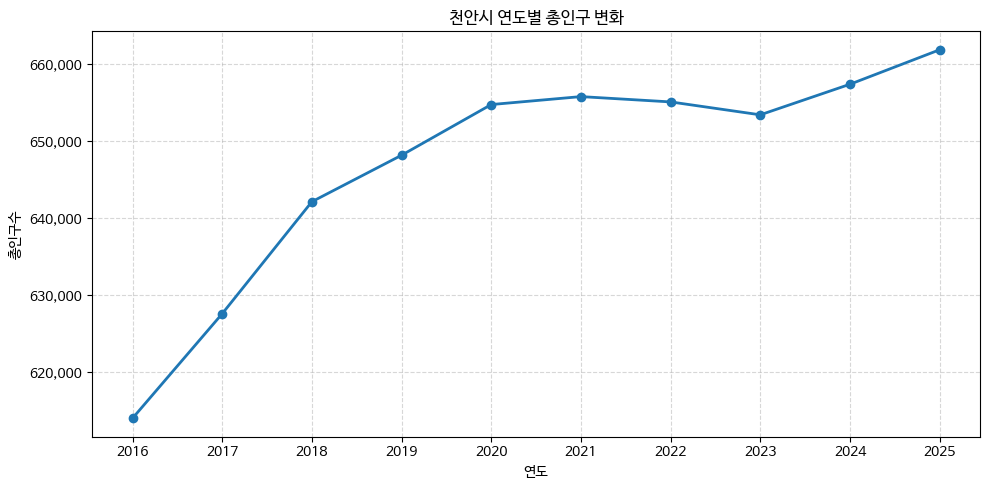

In [29]:
# 연도별 총인구 변화 시각화
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 5))
plt.plot(yearly_total['연도'], yearly_total['총인구수'], marker='o', linewidth=2)
plt.title('천안시 연도별 총인구 변화')
plt.xlabel('연도')
plt.ylabel('총인구수')
plt.xticks(yearly_total['연도'])
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot('01_천안시_연도별_총인구_변화')
plt.show()

그래프 저장 완료: output_graphs/02_천안시_인구_세대_세대당인구_변화.png


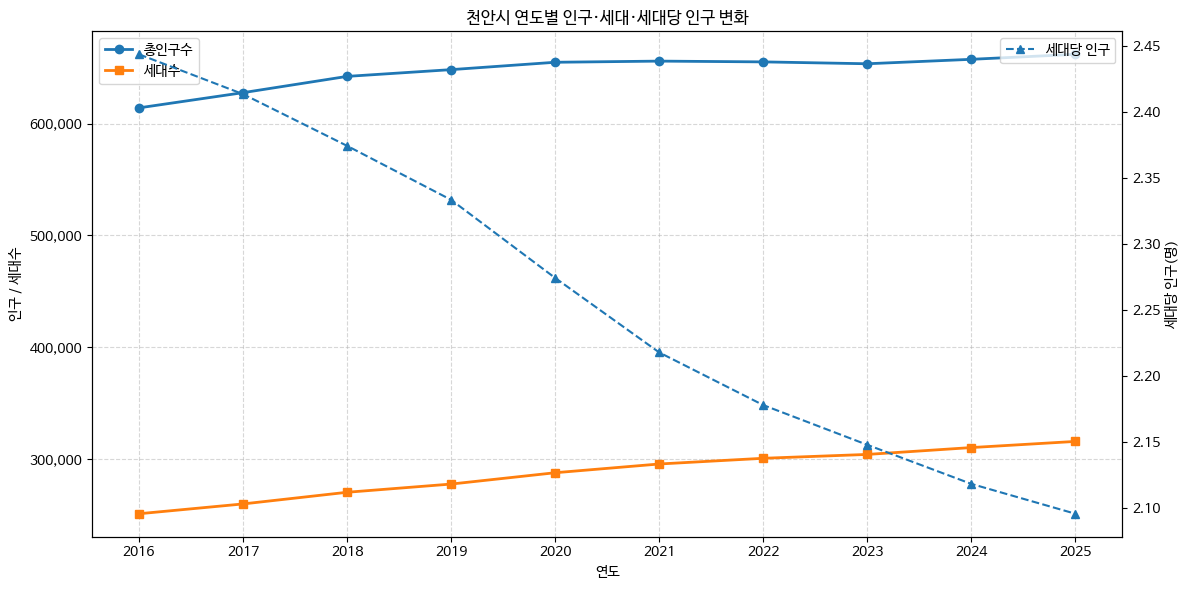

In [30]:
# 총인구수, 세대수, 세대당 인구를 함께 확인한다.
# 총인구수·세대수는 규모가 크고, 세대당 인구는 2명 안팎이므로 오른쪽 보조축을 사용한다.

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly_total['연도'], yearly_total['총인구수'], marker='o', label='총인구수', linewidth=2)
ax1.plot(yearly_total['연도'], yearly_total['세대수'], marker='s', label='세대수', linewidth=2)
ax1.set_xlabel('연도')
ax1.set_ylabel('인구 / 세대수')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(yearly_total['연도'], yearly_total['세대당인구'], marker='^', linestyle='--', label='세대당 인구')
ax2.set_ylabel('세대당 인구(명)')
ax2.legend(loc='upper right')

plt.title('천안시 연도별 인구·세대·세대당 인구 변화')
plt.xticks(yearly_total['연도'])
plt.tight_layout()
save_plot('02_천안시_인구_세대_세대당인구_변화')
plt.show()

### 해석 체크포인트

1. 총인구수는 증가, 정체, 감소 중 어느 흐름에 가까운가?
2. 세대수는 총인구수와 같은 방향으로 움직이는가?
3. 세대수는 늘지만 세대당 인구가 줄어든다면 어떤 생활 구조 변화를 의심할 수 있는가?
4. 이 자료만으로 청년 유출이나 고령화를 단정할 수 있는가?

> 핵심 원칙: 세대당 인구 감소는 소규모 가구 증가 가능성을 보여주지만, 청년 유출·고령화 여부를 직접 증명하지는 않는다. 이를 확인하려면 연령별 인구, 전입·전출, 주택 유형 등의 추가 데이터가 필요하다.

## 4. 핵심 분석 ③ 특정 행정구역 분석

전체 천안시 흐름만 보면 지역별 차이가 가려질 수 있다. 따라서 특정 읍·면·동을 선택해 총인구수, 세대수, 세대당 인구, 성별 인구 변화를 확인한다.

In [241]:
#불당동은 인구가 유입되면서 2개의 동으로 나뉨
# 3개의 동 인구 데이터가 누락된것처럼 보이는것을 방지하기 위해
# '불당동', '불당1동', '불당2동' 데이터를 하나로 합치는 작업

buldang_regions = ['충청남도 천안시 서북구 불당동(4413356500)',
                  '충청남도 천안시 서북구 불당1동(4413356600)',
                  '충청남도 천안시 서북구 불당2동(4413356700)']

# 해당 지역들의 데이터를 필터링
buldang_data = long_df[long_df['행정구역'].isin(buldang_regions)].copy()

# 연도별로 그룹화하고 주요 지표 합산
combined_buldang = buldang_data.groupby('연도').agg({
    '총인구수': 'sum',
    '세대수': 'sum',
    '남자인구수': 'sum',
    '여자인구수': 'sum'
}).reset_index()

# '행정구역' 컬럼 추가 및 '기준월' 설정
combined_buldang['행정구역'] = '충청남도 천안시 서북구 불당동(통합)'
combined_buldang['기준월'] = 12 # 12월 기준으로 통일

# 세대당인구와 남여비율 재계산
combined_buldang['세대당인구'] = combined_buldang['총인구수'] / combined_buldang['세대수']
combined_buldang['남여비율'] = combined_buldang['남자인구수'] / combined_buldang['여자인구수'] * 100

# 원본 long_df에서 기존 불당동 관련 지역 데이터 삭제
long_df = long_df[~long_df['행정구역'].isin(buldang_regions)].copy()

# 합쳐진 불당동 데이터를 long_df에 추가
long_df = pd.concat([long_df, combined_buldang], ignore_index=True)

print("불당동 지역 데이터 통합 완료.")

# 통합 후 행정구역 목록 및 불당동 데이터 확인
print("\n통합 후 행정구역 목록:")
print(sorted(long_df['행정구역'].unique()))

print("\n통합된 불당동 데이터 (상위 5개 행):")
display(long_df[long_df['행정구역'] == '충청남도 천안시 서북구 불당동(통합)'].head())

불당동 지역 데이터 통합 완료.

통합 후 행정구역 목록:
['충청남도 천안시 동남구 광덕면(4413132000)', '충청남도 천안시 동남구 동면(4413137000)', '충청남도 천안시 동남구 목천읍(4413125000)', '충청남도 천안시 동남구 문성동(4413152000)', '충청남도 천안시 동남구 병천면(4413136000)', '충청남도 천안시 동남구 봉명동(4413155000)', '충청남도 천안시 동남구 북면(4413133000)', '충청남도 천안시 동남구 성남면(4413134000)', '충청남도 천안시 동남구 수신면(4413135000)', '충청남도 천안시 동남구 신방동(4413157000)', '충청남도 천안시 동남구 신안동(4413159000)', '충청남도 천안시 동남구 원성1동(4413153000)', '충청남도 천안시 동남구 원성2동(4413154000)', '충청남도 천안시 동남구 일봉동(4413156000)', '충청남도 천안시 동남구 중앙동(4413151000)', '충청남도 천안시 동남구 청룡동(4413158000)', '충청남도 천안시 동남구 풍세면(4413131000)', '충청남도 천안시 서북구 백석동(4413356000)', '충청남도 천안시 서북구 부성1동(4413358000)', '충청남도 천안시 서북구 부성2동(4413359000)', '충청남도 천안시 서북구 불당동(통합)', '충청남도 천안시 서북구 성거읍(4413325300)', '충청남도 천안시 서북구 성정1동(4413351000)', '충청남도 천안시 서북구 성정2동(4413352000)', '충청남도 천안시 서북구 성환읍(4413325000)', '충청남도 천안시 서북구 쌍용1동(4413353000)', '충청남도 천안시 서북구 쌍용2동(4413354000)', '충청남도 천안시 서북구 쌍용3동(4413355000)', '충청남도 천안시 서북구 입장면(4413331000)', '충청남도 천안시 서북구 직산읍(4413325600)']

통합된 불당

,행정구역,연도,기준월,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
290,충청남도 천안시 서북구 불당동(통합),2016,12,37152.0,12502.0,2.971685,18630.0,18522.0,100.583090
291,충청남도 천안시 서북구 불당동(통합),2017,12,51061.0,17321.0,2.947924,25566.0,25495.0,100.278486
292,충청남도 천안시 서북구 불당동(통합),2018,12,63809.0,22413.0,2.846964,31997.0,31812.0,100.581542
293,충청남도 천안시 서북구 불당동(통합),2019,12,67151.0,24429.0,2.748823,33675.0,33476.0,100.594456
294,충청남도 천안시 서북구 불당동(통합),2020,12,69766.0,25851.0,2.698774,34975.0,34791.0,100.528872


In [246]:
# 행정구역 목록 확인
regions = sorted(long_df['행정구역'].unique())
print('행정구역 목록')
for i, region in enumerate(regions):
    print(i, region)

행정구역 목록
0 충청남도 천안시 동남구 광덕면(4413132000)
1 충청남도 천안시 동남구 동면(4413137000)
2 충청남도 천안시 동남구 목천읍(4413125000)
3 충청남도 천안시 동남구 문성동(4413152000)
4 충청남도 천안시 동남구 병천면(4413136000)
5 충청남도 천안시 동남구 봉명동(4413155000)
6 충청남도 천안시 동남구 북면(4413133000)
7 충청남도 천안시 동남구 성남면(4413134000)
8 충청남도 천안시 동남구 수신면(4413135000)
9 충청남도 천안시 동남구 신방동(4413157000)
10 충청남도 천안시 동남구 신안동(4413159000)
11 충청남도 천안시 동남구 원성1동(4413153000)
12 충청남도 천안시 동남구 원성2동(4413154000)
13 충청남도 천안시 동남구 일봉동(4413156000)
14 충청남도 천안시 동남구 중앙동(4413151000)
15 충청남도 천안시 동남구 청룡동(4413158000)
16 충청남도 천안시 동남구 풍세면(4413131000)
17 충청남도 천안시 서북구 백석동(4413356000)
18 충청남도 천안시 서북구 부성1동(4413358000)
19 충청남도 천안시 서북구 부성2동(4413359000)
20 충청남도 천안시 서북구 불당동(통합)
21 충청남도 천안시 서북구 성거읍(4413325300)
22 충청남도 천안시 서북구 성정1동(4413351000)
23 충청남도 천안시 서북구 성정2동(4413352000)
24 충청남도 천안시 서북구 성환읍(4413325000)
25 충청남도 천안시 서북구 쌍용1동(4413353000)
26 충청남도 천안시 서북구 쌍용2동(4413354000)
27 충청남도 천안시 서북구 쌍용3동(4413355000)
28 충청남도 천안시 서북구 입장면(4413331000)
29 충청남도 천안시 서북구 직산읍(4413325600)


In [247]:
# 분석할 지역 선택 원하는 지역명이 있으면 selected_region에 직접 입력한다.
# 예: selected_region = '충청남도 천안시 서북구 불당2동(4413356700)'
selected_region = regions[0]

# 특정 문자열이 포함된 지역을 찾고 싶을 때 사용한다.
# 예: '목천읍', '불당', '쌍용' 등
keyword = '불당동(통합)'
matched = [r for r in regions if keyword in r]
if matched:
    selected_region = matched[0]
region_data = long_df[long_df['행정구역'] == selected_region].sort_values('연도').copy()
print('선택된 지역:', selected_region)
#display(region_data)

선택된 지역: 충청남도 천안시 서북구 불당동(통합)


그래프 저장 완료: output_graphs/combined_불당동_인구_세대_성별_변화.png


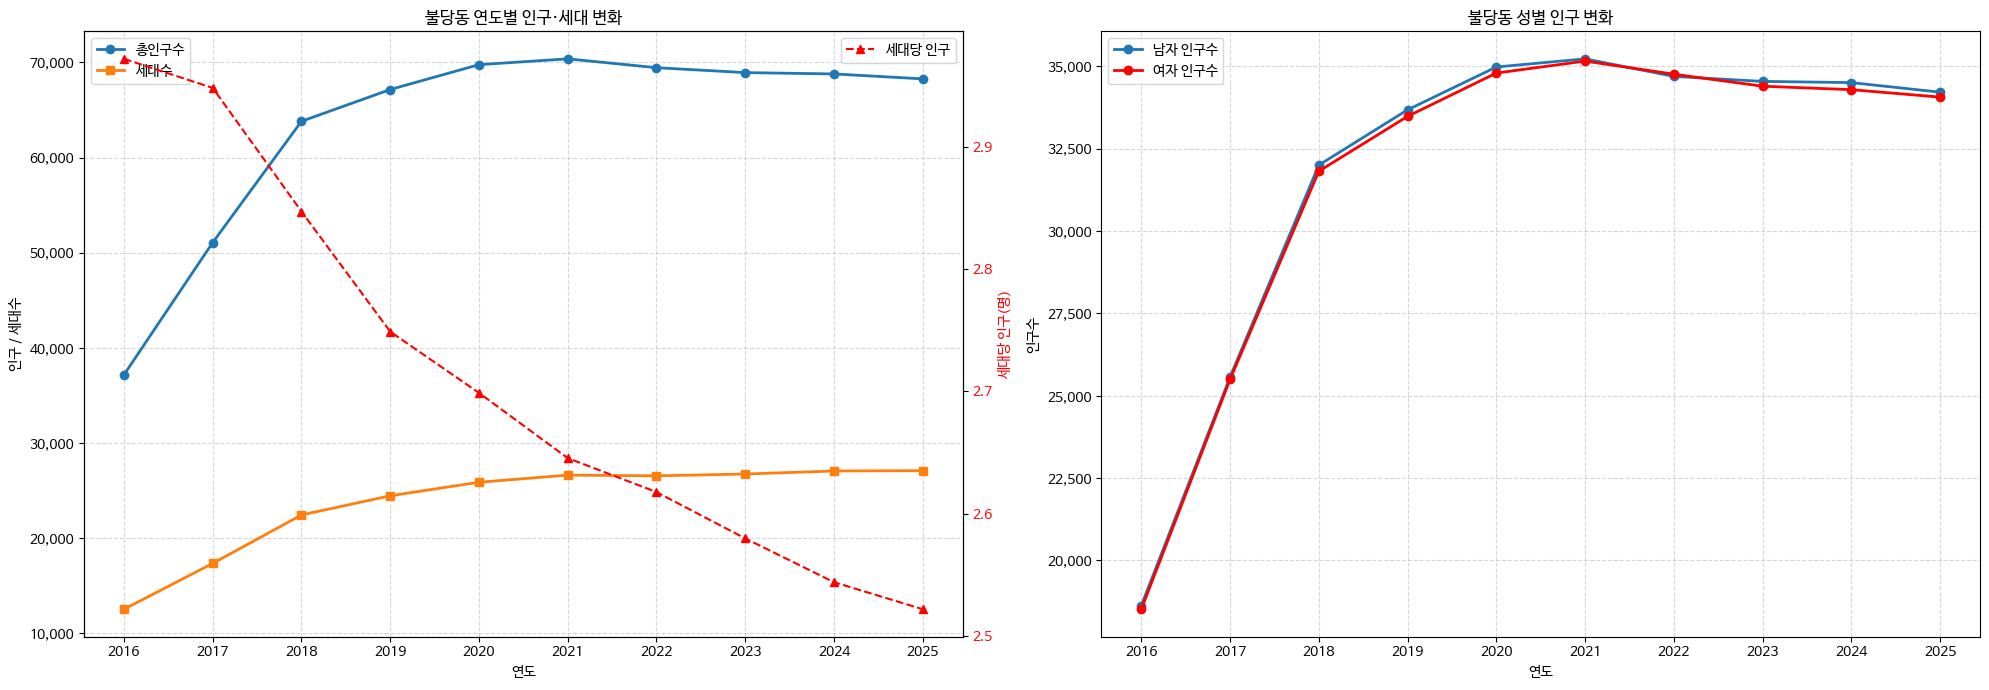

In [248]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# region_name을 selected_region에서 추출하여 업데이트
region_name = selected_region.split(' ')[-1].split('(')[0]

fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # 1행 2열의 서브플롯 생성

# 첫 번째 서브플롯: 인구·세대 변화
ax1 = axes[0]
ax1.plot(region_data['연도'], region_data['총인구수'], marker='o', label='총인구수', linewidth=2)
ax1.plot(region_data['연도'], region_data['세대수'], marker='s', label='세대수', linewidth=2)
ax1.set_xlabel('연도')
ax1.set_ylabel('인구 / 세대수')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax1_twin = ax1.twinx()
ax1_twin.plot(region_data['연도'], region_data['세대당인구'], marker='^', linestyle='--', label='세대당 인구', color='red')
ax1_twin.set_ylabel('세대당 인구(명)', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1_twin.legend(loc='upper right')
ax1.set_title(f'{region_name} 연도별 인구·세대 변화')
ax1.set_xticks(region_data['연도'])

# 두 번째 서브플롯: 성별 인구 변화
ax2 = axes[1]
ax2.plot(region_data['연도'], region_data['남자인구수'], marker='o', label='남자 인구수', linewidth=2)
ax2.plot(region_data['연도'], region_data['여자인구수'], marker='o',color='red', label='여자 인구수', linewidth=2)
ax2.set_title(f'{region_name} 성별 인구 변화')
ax2.set_xlabel('연도')
ax2.set_ylabel('인구수')
ax2.set_xticks(region_data['연도'])
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout() # 서브플롯 간의 간격 자동 조정
save_plot(f'combined_{region_name}_인구_세대_성별_변화') # 단일 파일로 저장
plt.show()

## 5. 핵심 분석 ④ 행정구역별 변화율 비교

지역문제 해결 프로젝트에서는 “어느 지역이 많이 늘었는가?”보다 “어느 지역의 변화가 두드러지는가?”를 보는 것이 중요하다. 여기서는 첫해와 마지막 해의 인구를 비교하여 행정구역별 변화율을 계산한다.

### 사용 공식

`기간 변화율 = (마지막 연도 인구 - 첫 연도 인구) ÷ 첫 연도 인구 × 100`

이 지표는 분석 기간 전체에서 인구가 어느 정도 변했는지를 보여준다.

### 왜 이 공식을 사용하는가?

단순 증감수는 인구 규모가 큰 지역에서 크게 나타나기 쉽다. 변화율은 각 지역의 출발 인구를 기준으로 변화 정도를 비교할 수 있게 해준다. 다만 변화율만 보면 인구가 적은 지역의 변화가 과장될 수 있으므로, 반드시 증감수와 함께 확인한다.

In [256]:
first_year = long_df['연도'].min()
last_year = long_df['연도'].max()

first_df = long_df[long_df['연도'] == first_year][['행정구역', '총인구수']].rename(columns={'총인구수': f'{first_year}년 인구'})
last_df = long_df[long_df['연도'] == last_year][['행정구역', '총인구수', '세대당인구', '남여비율']].rename(columns={'총인구수': f'{last_year}년 인구'})

change_df = pd.merge(first_df, last_df, on='행정구역', how='inner')
change_df['인구증감수'] = change_df[f'{last_year}년 인구'] - change_df[f'{first_year}년 인구']
change_df['기간변화율'] = change_df['인구증감수'] / change_df[f'{first_year}년 인구'] * 100
change_df = change_df.sort_values('기간변화율', ascending=False)

change_view = change_df.copy()
change_view['기간변화율'] = change_view['기간변화율'].round(2)
change_view['세대당인구'] = change_view['세대당인구'].round(2)
change_view['남여비율'] = change_view['남여비율'].round(2)

print('[기간 변화율 상위 10개 지역]')
display(change_view.head(10))
print('[기간 변화율 하위 10개 지역]')
display(change_view.tail(10))

[기간 변화율 상위 10개 지역]


,행정구역,2016년 인구,2025년 인구,세대당인구,남여비율,인구증감수,기간변화율
1,충청남도 천안시 동남구 풍세면(4413131000),4394.0,10608.0,1.95,111.27,6214.0,141.42
29,충청남도 천안시 서북구 불당동(통합),37152.0,68272.0,2.52,100.44,31120.0,83.76
9,충청남도 천안시 동남구 문성동(4413152000),4470.0,7742.0,2.01,102.14,3272.0,73.20
27,충청남도 천안시 서북구 부성1동(4413358000),36356.0,55295.0,1.95,107.61,18939.0,52.09
28,충청남도 천안시 서북구 부성2동(4413359000),42725.0,63539.0,2.31,112.19,20814.0,48.72
15,충청남도 천안시 동남구 청룡동(4413158000),48172.0,59625.0,2.43,100.27,11453.0,23.78
16,충청남도 천안시 동남구 신안동(4413159000),31174.0,37977.0,1.86,93.37,6803.0,21.82
26,충청남도 천안시 서북구 백석동(4413356000),38416.0,40305.0,2.64,101.60,1889.0,4.92
21,충청남도 천안시 서북구 성정1동(4413351000),17321.0,16635.0,1.77,112.67,-686.0,-3.96
18,충청남도 천안시 서북구 성거읍(4413325300),22987.0,21262.0,2.06,111.63,-1725.0,-7.50


[기간 변화율 하위 10개 지역]


,행정구역,2016년 인구,2025년 인구,세대당인구,남여비율,인구증감수,기간변화율
0,충청남도 천안시 동남구 목천읍(4413125000),26499.0,21843.0,1.97,105.18,-4656.0,-17.57
5,충청남도 천안시 동남구 수신면(4413135000),2466.0,2031.0,1.65,127.69,-435.0,-17.64
8,충청남도 천안시 동남구 중앙동(4413151000),5597.0,4474.0,1.62,109.75,-1123.0,-20.06
25,충청남도 천안시 서북구 쌍용3동(4413355000),21277.0,16938.0,2.11,92.83,-4339.0,-20.39
23,충청남도 천안시 서북구 쌍용1동(4413353000),15536.0,12313.0,2.02,96.94,-3223.0,-20.75
10,충청남도 천안시 동남구 원성1동(4413153000),9545.0,7541.0,1.90,106.15,-2004.0,-21.00
17,충청남도 천안시 서북구 성환읍(4413325000),27609.0,21550.0,1.95,108.70,-6059.0,-21.95
4,충청남도 천안시 동남구 성남면(4413134000),3552.0,2764.0,1.80,113.27,-788.0,-22.18
20,충청남도 천안시 서북구 입장면(4413331000),9605.0,7394.0,1.80,119.99,-2211.0,-23.02
11,충청남도 천안시 동남구 원성2동(4413154000),11751.0,8491.0,1.80,104.31,-3260.0,-27.74


그래프 저장 완료: output_graphs/05_행정구역별_인구_변화율_2016_2025.png


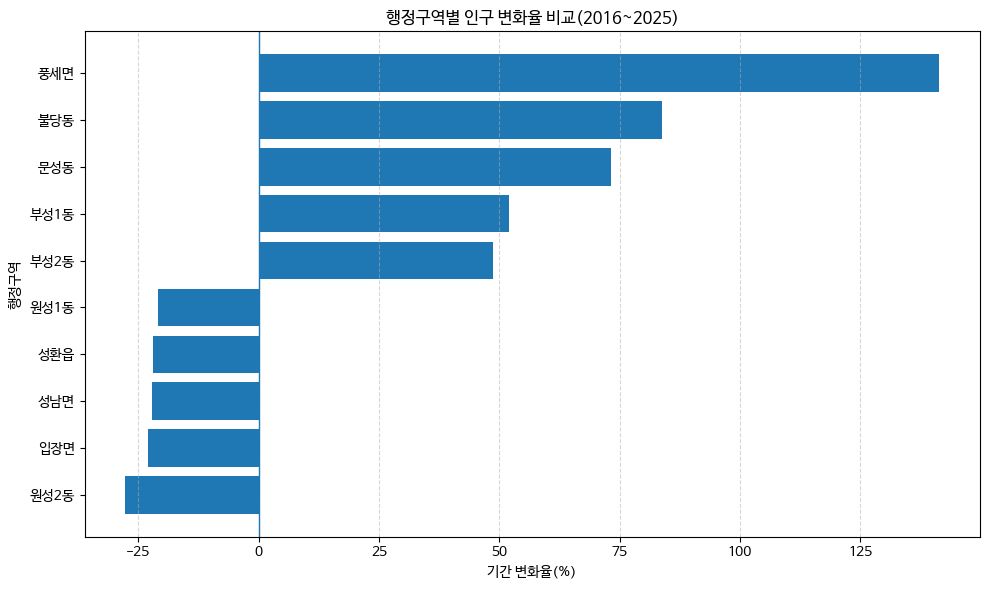

In [257]:
# 변화율 상위·하위 지역 시각화
plot_df = pd.concat([change_df.head(5), change_df.tail(5)]).copy()
plot_df['지역명'] = plot_df['행정구역'].str.split(' ').str[-1].str.split('(').str[0]
plot_df = plot_df.sort_values('기간변화율')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['지역명'], plot_df['기간변화율'])
plt.axvline(0, linewidth=1)
plt.title(f'행정구역별 인구 변화율 비교({first_year}~{last_year})')
plt.xlabel('기간 변화율(%)')
plt.ylabel('행정구역')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot(f'05_행정구역별_인구_변화율_{first_year}_{last_year}')
plt.show()

2016년부터 2025년까지 각 행정구역의 인구 변화율을 비교한것으로 가로축은 기간 변화율(%)을 나타냅니다. 막대의 길이는 해당 지역의 인구 변화율을 의미하며, 0%를 기준으로 오른쪽은 인구 증가, 왼쪽은 인구 감소를 나타냅니다.

그래프는 일부 지역에서 두드러진 인구 유입 또는 유출이 있었음을 시각적으로 보여줍니다. 특히 '풍세면'과 '불당동(통합)' 같은 지역은 매우 가파른 성장세를 경험한 반면, '원성2동' 등 일부 지역은 상당한 인구 감소를 겪었음을 알 수 있습니다.

## 6. 심화 분석 ① K-Means 클러스터링

### 이 알고리즘은 왜 사용하는가?

K-Means 클러스터링은 비슷한 특징을 가진 데이터를 자동으로 묶는 분석 방법이다. 이 수업에서는 가장 최근 연도 자료를 기준으로 `세대당인구`와 `남여비율`이 비슷한 지역을 3개 집단으로 나누어 본다.

### 고등학생 프로젝트에서의 적절성

이 분석은 **필수 분석이 아니라 심화 분석**으로 사용하는 것이 적절하다. 이유는 다음과 같다.

1. 클러스터링은 원인을 설명하는 알고리즘이 아니라, 비슷한 대상을 묶는 탐색적 방법이다.
2. 현재 사용하는 변수는 `세대당인구`와 `남여비율`뿐이므로, 지역 유형을 제한적으로만 설명할 수 있다.
3. 청년 유출, 고령화, 산업 구조, 주거 문제를 설명하려면 추가 데이터가 필요하다.

### 왜 표준화를 하는가?

`세대당인구`는 보통 1~3 정도의 값이고, `남여비율`은 90~110 정도의 값이다. 숫자 크기가 다른 두 지표를 그대로 사용하면 값의 범위가 큰 남여비율이 더 큰 영향을 줄 수 있다. 따라서 평균을 0, 표준편차를 1로 맞추는 표준화를 수행한다.

### 표준화 공식

`표준화 값 z = (원래 값 - 평균) ÷ 표준편차`

### 해석 가능 범위

- 적절한 해석: “세대당 인구와 성비가 비슷한 지역끼리 묶였다.”
- 부적절한 해석: “이 지역은 청년 유출 지역이다.”, “이 지역은 고령화 지역이다.”

In [258]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

latest_year = long_df['연도'].max()
latest = long_df[long_df['연도'] == latest_year].copy()

features = latest[['세대당인구', '남여비율']].dropna()
latest = latest.loc[features.index].copy()

# 표준화: 서로 다른 단위의 변수를 비교 가능한 값으로 변환한다.
scaler = StandardScaler()
X = scaler.fit_transform(features)

# K-Means 군집분석
# n_clusters=3은 수업용으로 단순화한 값이다. 실제 연구에서는 여러 k값을 비교해야 한다.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
latest['클러스터'] = kmeans.fit_predict(X)

print(f'{latest_year}년 기준 {len(latest)}개 행정구역을 3개 유형으로 분류했습니다.')
display(latest[['행정구역', '세대당인구', '남여비율', '클러스터']].head())

2025년 기준 30개 행정구역을 3개 유형으로 분류했습니다.


,행정구역,세대당인구,남여비율,클러스터
9,충청남도 천안시 동남구 목천읍(4413125000),1.971568,105.175653,0
19,충청남도 천안시 동남구 풍세면(4413131000),1.952512,111.272655,0
29,충청남도 천안시 동남구 광덕면(4413132000),1.750556,101.072523,0
39,충청남도 천안시 동남구 북면(4413133000),1.682008,108.506224,0
49,충청남도 천안시 동남구 성남면(4413134000),1.798308,113.271605,0


In [259]:
# 클러스터별 평균값 확인
cluster_summary = latest.groupby('클러스터').agg({
    '행정구역': 'count',
    '세대당인구': 'mean',
    '남여비율': 'mean'
}).rename(columns={'행정구역': '지역수'}).reset_index()

cluster_summary['세대당인구'] = cluster_summary['세대당인구'].round(2)
cluster_summary['남여비율'] = cluster_summary['남여비율'].round(2)

display(cluster_summary)

,클러스터,지역수,세대당인구,남여비율
0,0,16,1.87,106.04
1,1,8,2.37,100.96
2,2,6,1.68,123.20


## 클러스터별 해당 행정구역 확인하기

클러스터링을 수행한 뒤에는 각 유형에 어떤 읍·면·동이 포함되었는지 반드시 확인해야 한다.  
클러스터 번호 자체에는 의미가 없다. 예를 들어 `클러스터 0`이 좋거나 나쁜 지역이라는 뜻은 아니다.  
학생들은 각 클러스터에 속한 행정구역 목록과 평균값을 함께 보면서 유형 이름을 직접 붙여야 한다.

> 주의: 현재 분류 기준은 `세대당인구`와 `남여비율`뿐이다. 따라서 이 결과만으로 청년 유출, 고령화, 산업 쇠퇴를 단정할 수 없다.

In [260]:
# 클러스터별 행정구역 목록 정리
cluster_region_list = (
    latest
    .assign(지역명=latest['행정구역'].str.split(' ').str[-1].str.split('(').str[0])
    .sort_values(['클러스터', '지역명'])
    .groupby('클러스터')['지역명']
    .apply(lambda x: ', '.join(x))
    .reset_index()
    .rename(columns={'지역명': '해당 행정구역'})
)

cluster_result_table = cluster_summary.merge(cluster_region_list, on='클러스터', how='left')
display(cluster_result_table)

,클러스터,지역수,세대당인구,남여비율,해당 행정구역
0,0,16,1.87,106.04,"광덕면, 목천읍, 문성동, 봉명동, 부성1동, 북면, 성거읍, 성남면, 성정1동, ..."
1,1,8,2.37,100.96,"백석동, 부성2동, 불당동, 신방동, 쌍용2동, 쌍용3동, 일봉동, 청룡동"
2,2,6,1.68,123.20,"동면, 병천면, 성정2동, 수신면, 입장면, 직산읍"


## 클러스터 유형 이름 붙이기 활동

아래 코드는 각 클러스터의 평균값을 기준으로 임시 유형명을 만든다.  
단, 이 이름은 절대적인 진단명이 아니라 수업용 해석 보조 문장이다. 학생들은 표와 그래프를 보고 더 적절한 이름으로 바꿀 수 있다.

In [261]:
# 클러스터 평균값을 바탕으로 수업용 유형명 자동 생성
overall_household = latest['세대당인구'].mean()
overall_gender = latest['남여비율'].mean()

def make_cluster_label(row):
    household_part = '세대당 인구 높음' if row['세대당인구'] >= overall_household else '세대당 인구 낮음'
    gender_part = '남성 비율 높음' if row['남여비율'] >= overall_gender else '남성 비율 낮음'
    return f'{household_part} · {gender_part} 유형'

cluster_result_table['유형명'] = cluster_result_table.apply(make_cluster_label, axis=1)

display(cluster_result_table[['클러스터', '유형명', '지역수', '세대당인구', '남여비율', '해당 행정구역']])

,클러스터,유형명,지역수,세대당인구,남여비율,해당 행정구역
0,0,세대당 인구 낮음 · 남성 비율 낮음 유형,16,1.87,106.04,"광덕면, 목천읍, 문성동, 봉명동, 부성1동, 북면, 성거읍, 성남면, 성정1동, ..."
1,1,세대당 인구 높음 · 남성 비율 낮음 유형,8,2.37,100.96,"백석동, 부성2동, 불당동, 신방동, 쌍용2동, 쌍용3동, 일봉동, 청룡동"
2,2,세대당 인구 낮음 · 남성 비율 높음 유형,6,1.68,123.20,"동면, 병천면, 성정2동, 수신면, 입장면, 직산읍"


## 클러스터별 정책 제안 질답 활동

클러스터링 결과는 정책을 자동으로 정해주는 도구가 아니다.  
정책 제안은 반드시 다음 순서로 작성한다.

1. 데이터에서 확인한 특징을 쓴다.  
2. 그 특징으로부터 가능한 지역 문제를 질문 형태로 만든다.  
3. 단정하기 어려운 부분과 추가로 필요한 데이터를 적는다.  
4. 확인 가능한 범위 안에서 정책 아이디어를 제안한다.

### 질답 예시

**Q1. 이 클러스터는 어떤 특징을 보이는가?**  
A. 세대당 인구와 남여비율의 평균을 기준으로 볼 때, 다른 지역과 구분되는 패턴을 보인다.

**Q2. 이 결과만으로 어떤 문제를 단정할 수 있는가?**  
A. 단정할 수 없다. 현재 데이터는 주민등록인구, 세대수, 성별 인구 중심이므로 청년 유출, 고령화, 교통 불편, 주거 문제를 직접 증명하지 못한다.

**Q3. 정책을 제안하려면 어떤 추가 데이터가 필요한가?**  
A. 연령별 인구, 전입·전출, 1인 가구, 주택 유형, 학교·복지시설·교통 접근성, 사업체 수 등의 데이터가 필요하다.

**Q4. 그래도 현재 데이터로 제안할 수 있는 정책 방향은 무엇인가?**  
A. 확정적 처방이 아니라 가설적 정책 방향을 제안할 수 있다. 예를 들어 세대당 인구가 낮은 지역은 1인 가구 지원, 생활 편의 서비스, 안전망 정책을 검토할 수 있다. 세대당 인구가 높은 지역은 돌봄, 교육, 가족 단위 생활 인프라를 검토할 수 있다.

In [262]:
# 클러스터별 정책 제안 작성용 질답 템플릿 자동 생성
policy_questions = []

for _, row in cluster_result_table.iterrows():
    cluster_id = row['클러스터']
    label = row.get('유형', f'클러스터 {cluster_id}')
    regions = row['해당 행정구역']
    household = row['세대당인구']
    gender_ratio = row['남여비율']

    policy_questions.append({
        '클러스터': cluster_id,
        '유형': label,
        '해당 행정구역': regions,
        'Q1. 데이터에서 보이는 특징은?': f'세대당 인구 평균은 {household}명, 남여비율은 {gender_ratio}이다. 이 값이 전체 평균보다 높은지 낮은지 비교한다.',
        'Q2. 이 결과만으로 단정할 수 없는 것은?': '청년 유출, 고령화, 지역 쇠퇴, 산업 구조 문제는 현재 데이터만으로 단정할 수 없다.',
        'Q3. 추가로 확인할 데이터는?': '연령별 인구, 전입·전출, 1인 가구, 주택 유형, 학교·복지·교통·일자리 데이터',
        'Q4. 검토 가능한 정책 방향은?': '지역 특성에 맞는 생활 인프라, 돌봄, 교통, 청년·가족·1인 가구 지원 정책을 가설로 제안한다.',
        '학생 작성란': '이 클러스터에 필요한 정책을 근거와 함께 작성하세요.'
    })

policy_question_df = pd.DataFrame(policy_questions)
display(policy_question_df)

# 필요하면 CSV로 저장하여 학생 활동지로 활용할 수 있다.
policy_question_df.to_csv('cluster_policy_question_template.csv', index=False, encoding='utf-8-sig')
print('질답 활동지 저장 완료: cluster_policy_question_template.csv')

,클러스터,유형,해당 행정구역,Q1. 데이터에서 보이는 특징은?,Q2. 이 결과만으로 단정할 수 없는 것은?,Q3. 추가로 확인할 데이터는?,Q4. 검토 가능한 정책 방향은?,학생 작성란
0,0,클러스터 0,"광덕면, 목천읍, 문성동, 봉명동, 부성1동, 북면, 성거읍, 성남면, 성정1동, ...","세대당 인구 평균은 1.87명, 남여비율은 106.04이다. 이 값이 전체 평균보다...","청년 유출, 고령화, 지역 쇠퇴, 산업 구조 문제는 현재 데이터만으로 단정할 수 없다.","연령별 인구, 전입·전출, 1인 가구, 주택 유형, 학교·복지·교통·일자리 데이터","지역 특성에 맞는 생활 인프라, 돌봄, 교통, 청년·가족·1인 가구 지원 정책을 가...",이 클러스터에 필요한 정책을 근거와 함께 작성하세요.
1,1,클러스터 1,"백석동, 부성2동, 불당동, 신방동, 쌍용2동, 쌍용3동, 일봉동, 청룡동","세대당 인구 평균은 2.37명, 남여비율은 100.96이다. 이 값이 전체 평균보다...","청년 유출, 고령화, 지역 쇠퇴, 산업 구조 문제는 현재 데이터만으로 단정할 수 없다.","연령별 인구, 전입·전출, 1인 가구, 주택 유형, 학교·복지·교통·일자리 데이터","지역 특성에 맞는 생활 인프라, 돌봄, 교통, 청년·가족·1인 가구 지원 정책을 가...",이 클러스터에 필요한 정책을 근거와 함께 작성하세요.
2,2,클러스터 2,"동면, 병천면, 성정2동, 수신면, 입장면, 직산읍","세대당 인구 평균은 1.68명, 남여비율은 123.2이다. 이 값이 전체 평균보다 ...","청년 유출, 고령화, 지역 쇠퇴, 산업 구조 문제는 현재 데이터만으로 단정할 수 없다.","연령별 인구, 전입·전출, 1인 가구, 주택 유형, 학교·복지·교통·일자리 데이터","지역 특성에 맞는 생활 인프라, 돌봄, 교통, 청년·가족·1인 가구 지원 정책을 가...",이 클러스터에 필요한 정책을 근거와 함께 작성하세요.


질답 활동지 저장 완료: cluster_policy_question_template.csv


## 정책 제안 작성 시 사용할 수 있는 표현

아래 표현은 학생들이 보고서에 바로 활용할 수 있는 문장 구조이다.

- `클러스터 __에는 ____ 지역이 포함되었다.`
- `이 유형은 세대당 인구가 상대적으로 __고, 남여비율은 __한 특징을 보였다.`
- `다만 이 결과만으로 ____ 문제를 단정하기는 어렵다.`
- `이를 확인하기 위해서는 ____ 데이터가 추가로 필요하다.`
- `따라서 현재 자료를 바탕으로는 ____ 정책을 검토할 수 있다.`

### 정책 아이디어 예시

| 데이터상 특징 | 조심스러운 해석 | 추가 확인 데이터 | 검토 가능한 정책 방향 |
|---|---|---|---|
| 세대당 인구 낮음 | 1인 가구 또는 소규모 가구 가능성 | 1인 가구 수, 연령별 가구 구성 | 생활 편의, 안전, 고립 예방, 소형 주거 지원 |
| 세대당 인구 높음 | 가족 단위 거주 가능성 | 아동·청소년 인구, 학교 수 | 돌봄, 교육, 통학 안전, 공원·생활SOC |
| 남여비율 높음 | 남성 인구 비중이 상대적으로 높음 | 산업단지, 직장, 외국인, 연령별 성비 | 노동·주거·교통·안전 인프라 점검 |
| 남여비율 낮음 | 여성 인구 비중이 상대적으로 높음 | 연령별 성비, 1인 가구, 복지 수요 | 안전, 돌봄, 건강, 생활 편의 정책 |

그래프 저장 완료: output_graphs/06_클러스터링_지역유형화_2025.png


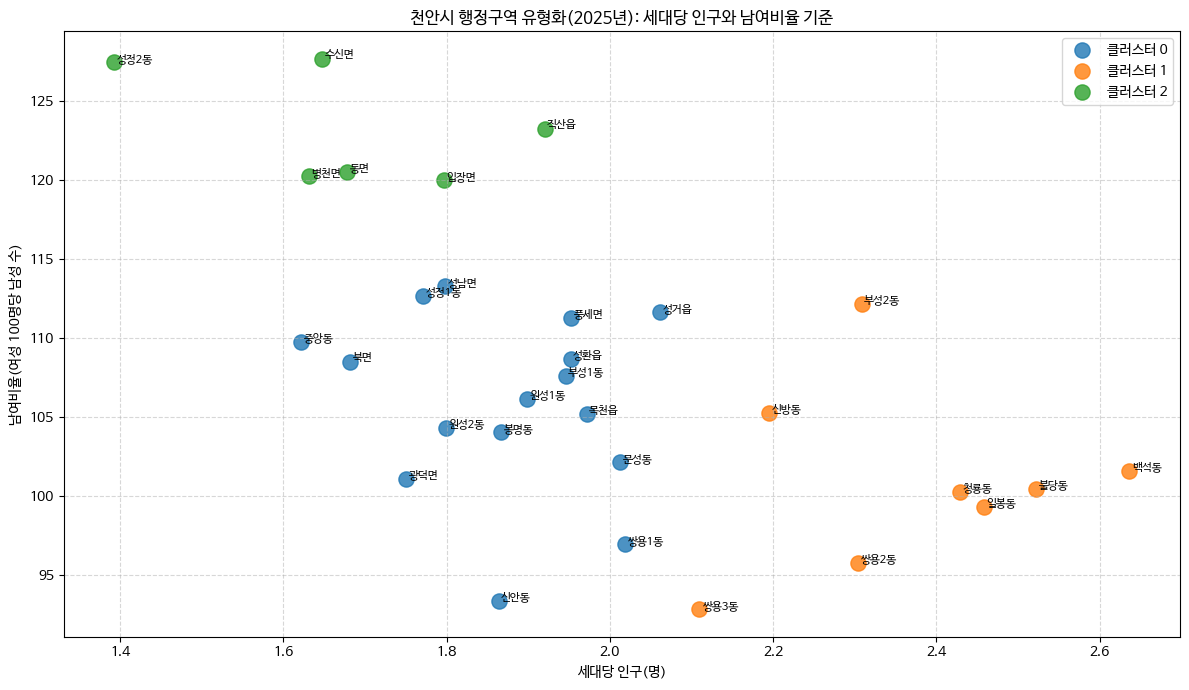

In [263]:
# 클러스터 시각화
plt.figure(figsize=(12, 7))

for cluster_id in sorted(latest['클러스터'].unique()):
    subset = latest[latest['클러스터'] == cluster_id]
    plt.scatter(subset['세대당인구'], subset['남여비율'], s=120, label=f'클러스터 {cluster_id}', alpha=0.8)

# 행정구역 이름 표시
for _, row in latest.iterrows():
    clean_name = row['행정구역'].split(' ')[-1].split('(')[0]
    plt.text(row['세대당인구'] + 0.003, row['남여비율'] + 0.03, clean_name, fontsize=8)

plt.title(f'천안시 행정구역 유형화({latest_year}년): 세대당 인구와 남여비율 기준')
plt.xlabel('세대당 인구(명)')
plt.ylabel('남여비율(여성 100명당 남성 수)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot(f'06_클러스터링_지역유형화_{latest_year}')
plt.show()

### 클러스터링 결과 해석 활동

아래 문장처럼 조심스럽게 해석한다.

- 적절한 해석: “이 집단은 세대당 인구가 상대적으로 높고 남여비율이 낮은 편이다.”
- 부적절한 해석: “이 집단은 청년이 많다.” 또는 “이 집단은 고령화 지역이다.”

청년·고령층 문제까지 분석하려면 다음 데이터가 추가로 필요하다.

- 연령별 인구: 0~14세, 15~64세, 65세 이상 등
- 청년 인구: 예를 들어 19~34세 또는 20~39세
- 전입·전출 데이터
- 주택 유형, 학교, 대중교통, 일자리, 상권 데이터

### 학생 활동 질문

1. 각 클러스터는 세대당 인구와 남여비율 기준으로 어떤 특징을 보이는가?
2. 같은 클러스터에 묶인 지역들은 실제로 지리적으로도 가까운가?
3. 이 결과를 더 정확하게 해석하려면 어떤 데이터를 추가해야 하는가?

4. 각 클러스터에 속한 행정구역 이름을 확인하고, 공통점이 있는지 설명해보자.
5. 각 클러스터에 필요한 정책을 한 가지 이상 제안하되, 반드시 데이터 근거와 추가 확인이 필요한 자료를 함께 적어보자.


## 7. 심화 분석 ② 미래 인구 변화 시나리오

이 단계는 정확한 미래 예측이 아니라 **가정 기반 시뮬레이션**이다. “만약 지금의 변화율이 계속된다면”, “정책으로 감소세가 완화된다면”과 같은 조건을 설정하고 결과가 어떻게 달라지는지 비교한다.

### 기본 공식

`다음 해 인구 = 올해 인구 × (1 + 변화율)`

여러 해를 계산할 때는 매년 새로 계산된 인구를 기준으로 다시 변화율을 적용한다. 복리 계산과 같은 구조이다.

### 왜 이 공식을 사용하는가?

인구 변화는 매년 이전 인구를 기준으로 발생한다. 따라서 10년 뒤 인구를 계산할 때는 단순히 한 번만 더하거나 빼는 것이 아니라, 전년도 인구에 변화율을 반복 적용하는 방식이 더 자연스럽다.

### 해석의 한계

실제 인구 변화에는 출생, 사망, 전입, 전출, 주택 공급, 산업단지 조성, 학교·교통망 변화 등이 영향을 준다. 따라서 이 결과는 “미래를 맞히는 예측값”이 아니라 “조건이 달라지면 결과도 달라진다는 것을 보여주는 탐구 도구”로 해석해야 한다.

In [265]:
# 선택 지역의 과거 연평균 변화율 계산
region_data = region_data.sort_values('연도').copy()
base_year = int(region_data['연도'].max())
base_pop = float(region_data.loc[region_data['연도'] == base_year, '총인구수'].iloc[0])

first_pop = float(region_data['총인구수'].iloc[0])
last_pop = float(region_data['총인구수'].iloc[-1])
period = len(region_data) - 1

# 연평균 변화율: 시작 인구에서 마지막 인구까지 매년 같은 비율로 변했다고 가정한 값
if period > 0 and first_pop > 0:
    trend_rate = (last_pop / first_pop) ** (1 / period) - 1
else:
    trend_rate = 0

print('선택 지역:', selected_region)
print('기준 연도:', base_year)
print('기준 인구:', f'{base_pop:,.0f}명')
print('분석 기간 연평균 변화율:', f'{trend_rate * 100:.2f}%')

선택 지역: 충청남도 천안시 서북구 불당동(통합)
기준 연도: 2025
기준 인구: 68,272명
분석 기간 연평균 변화율: 6.99%


In [268]:
overall_first_pop = float(yearly_total['총인구수'].iloc[0])
overall_last_pop = float(yearly_total['총인구수'].iloc[-1])
overall_period = len(yearly_total) - 1

if overall_period > 0 and overall_first_pop > 0:
    overall_trend_rate = (overall_last_pop / overall_first_pop) ** (1 / overall_period) - 1
else:
    overall_trend_rate = 0

print('\n천안시 전체 분석 기간 연평균 변화율:', f'{overall_trend_rate * 100:.2f}%')


천안시 전체 분석 기간 연평균 변화율: 0.84%


In [271]:
# 인구 시뮬레이션 함수
# rates에는 매년 적용할 변화율을 순서대로 넣는다.
def simulate_population(base_pop, rates):
    result = []
    pop = base_pop
    for r in rates:
        pop = pop * (1 + r)
        result.append(pop)
    return result

future_years = list(range(base_year + 1, base_year + 11))


#### 시나리오 1: 과거 연평균 변화율이 그대로 이어지는 경우

`scenario1_rates = [trend_rate] * 10`
`scenario1 = simulate_population(base_pop, scenario1_rates)`


#### 시나리오 2: 변화율이 10년에 걸쳐 0에 가까워지는 경우

감소 지역이면 감소가 완화되고, 증가 지역이면 증가세가 둔화되는 보수적 시나리오이다.

`scenario2_rates = np.linspace(trend_rate, 0, 10)`
`scenario2 = simulate_population(base_pop, scenario2_rates)`

#### 시나리오 3: 정책 개입으로 3년 뒤부터 연 1% 증가 또는 현 추세보다 개선되는 경우

단, 이는 정책 효과를 증명하는 값이 아니라 수업용 가정값이다.

In [272]:

target_rate = 0.01
scenario3_rates = list(np.linspace(trend_rate, target_rate, 3)) + [target_rate] * 7
scenario3 = simulate_population(base_pop, scenario3_rates)

scenario_df = pd.DataFrame({
    '연도': future_years,
    '시나리오1_현재추세': scenario1,
    '시나리오2_변화완화': scenario2,
    '시나리오3_정책개입가정': scenario3
})

display(scenario_df.round(0))

,연도,시나리오1_현재추세,시나리오2_변화완화,시나리오3_정책개입가정
0,2026,73047.0,73047.0,73047.0
1,2027,78157.0,77589.0,75967.0
2,2028,83624.0,81810.0,76727.0
3,2029,89473.0,85625.0,77494.0
4,2030,95731.0,88953.0,78269.0
5,2031,102427.0,91718.0,79052.0
6,2032,109592.0,93856.0,79842.0
7,2033,117258.0,95315.0,80641.0
8,2034,125459.0,96056.0,81447.0
9,2035,134235.0,96056.0,82262.0


그래프 저장 완료: output_graphs/07_불당동_향후10년_인구_시나리오.png


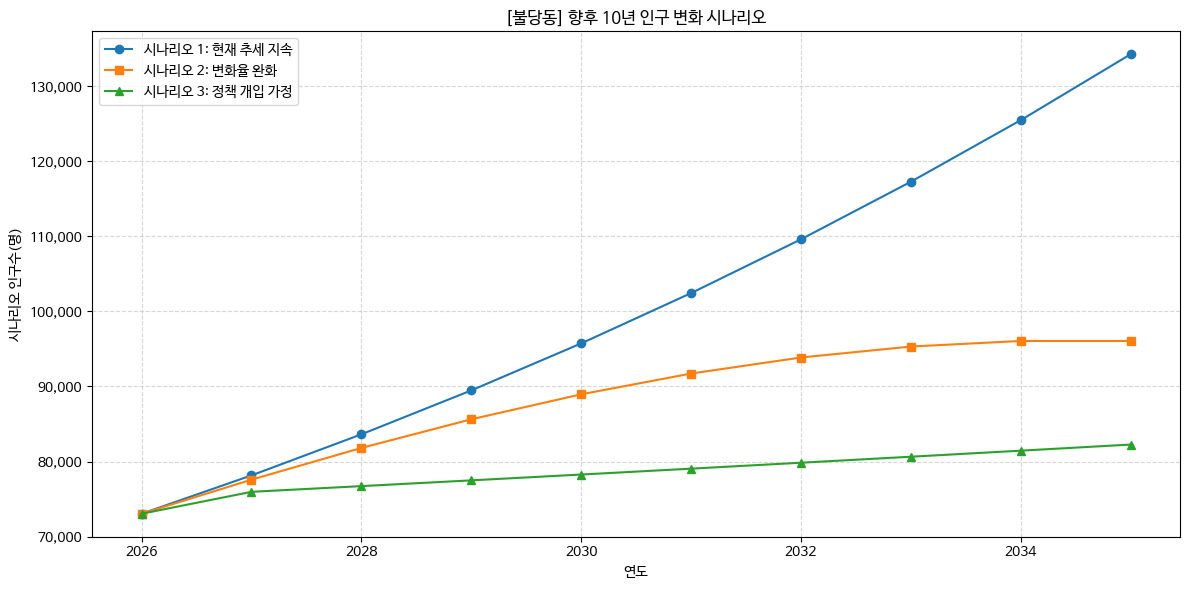

In [267]:
# 시나리오 결과 시각화
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
plt.plot(scenario_df['연도'], scenario_df['시나리오1_현재추세'], marker='o', label='시나리오 1: 현재 추세 지속')
plt.plot(scenario_df['연도'], scenario_df['시나리오2_변화완화'], marker='s', label='시나리오 2: 변화율 완화')
plt.plot(scenario_df['연도'], scenario_df['시나리오3_정책개입가정'], marker='^', label='시나리오 3: 정책 개입 가정')

plt.title(f'[{region_name}] 향후 10년 인구 변화 시나리오')
plt.xlabel('연도')
plt.ylabel('시나리오 인구수(명)')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot(f'07_{region_name}_향후10년_인구_시나리오')
plt.show()

### 시나리오 분석 결과 해석 활동

1. 세 가지 시나리오의 차이는 몇 년 뒤부터 커지는가?
2. 현재 추세가 지속될 때와 변화율이 완화될 때 결과는 얼마나 달라지는가?
3. 정책 개입 가정값 1%는 실제로 검증된 값인가, 수업용 가정값인가?
4. 실제 정책 효과를 분석하려면 어떤 자료가 더 필요한가?

> 주의: 이 분석은 정책 효과를 증명하지 않는다. 정책 아이디어를 세우기 전에 가능한 변화 방향을 가정해보는 탐구 도구이다.

## 8. 분석 알고리즘 적절성 정리

| 분석 방법 | 이 프로젝트에서의 역할 | 최종 판단 |
|---|---|---|
| 기초 통계 분석 | 데이터 규모와 기본 흐름 확인 | 핵심 분석으로 적절 |
| 연도별 집계 | 천안시 전체 변화 파악 | 핵심 분석으로 적절 |
| 세대당 인구·남여비율 | 비교 가능한 지표 생성 | 핵심 분석으로 적절 |
| 전년 대비 증감률·기간 변화율 | 변화 방향과 속도 확인 | 핵심 분석으로 적절 |
| 시각화 | 학생의 해석과 발표 지원 | 핵심 분석으로 적절 |
| K-Means 클러스터링 | 비슷한 지역 유형 탐색 | 심화 분석으로 적절 |
| 미래 인구 시나리오 | 가정에 따른 변화 가능성 탐색 | 심화 분석으로 적절 |

결론적으로 본 프로젝트의 알고리즘 구성은 고등학생 지역문제 해결 프로젝트에 적절하다. 다만 클러스터링과 미래 시나리오 분석은 원인 규명이나 정확한 예측을 위한 도구가 아니라, **추가 질문을 만들기 위한 탐색 도구**로 사용해야 한다.

## 9. 프로젝트 결과 정리 양식

분석 결과는 다음 구조로 정리한다.

### 1) 분석 대상
- 사용 데이터:
- 분석 기간:
- 분석 지역:
- 기준월:

### 2) 사용한 분석 방법
- 핵심 분석:
- 심화 분석:
- 각 분석 방법을 사용한 이유:

### 3) 핵심 지표
- 총인구수 변화:
- 세대수 변화:
- 세대당 인구 변화:
- 남여비율 변화:
- 전년 대비 증감률:
- 기간 변화율:

### 4) 데이터로 확인한 사실
예시: “인구는 크게 줄지 않았지만 세대당 인구가 감소하고 있다.”

### 5) 아직 단정할 수 없는 부분
예시: “세대당 인구 감소의 원인이 청년 유출인지, 고령화인지, 1인 가구 증가인지는 현재 데이터만으로 판단할 수 없다.”

### 6) 추가로 필요한 데이터
예시: 연령별 인구, 전입·전출, 주택 유형, 대중교통 접근성, 학교·복지시설 분포 등

### 7) 정책 아이디어
- 제안 정책:
- 이 정책이 필요한 이유:
- 기대 효과:
- 정책 효과를 검증하기 위한 추가 데이터:

## 최종 해석 예시

천안시 인구 데이터는 지역의 변화를 이해하는 출발점이 된다. 총인구수, 세대수, 세대당 인구, 남여비율을 함께 살펴보면 단순히 인구가 늘었는지 줄었는지를 넘어 지역의 생활 구조가 어떻게 달라지고 있는지 질문할 수 있다.

본 프로젝트에서 가장 중요한 분석은 연도별 집계, 비율 계산, 증감률 분석, 시각화이다. 이 방법들은 고등학생이 데이터의 흐름을 이해하고 지역별 차이를 설명하는 데 적절하다. K-Means 클러스터링과 미래 인구 시나리오 분석은 심화 활동으로 활용할 수 있으나, 결과를 과도하게 해석해서는 안 된다.

특히 세대당 인구 감소는 소규모 가구 증가 가능성을 보여주는 지표이지만, 그 원인이 청년 유출인지, 고령화인지, 주택 구조 변화인지는 현재 데이터만으로 단정할 수 없다. 이를 확인하려면 연령별 인구, 전입·전출, 주택 유형, 교통 접근성 등의 추가 자료가 필요하다.

따라서 본 프로젝트의 핵심은 하나의 그래프에서 결론을 확정하는 것이 아니라, 데이터를 바탕으로 더 나은 질문을 만들고 필요한 추가 자료를 제안하는 데 있다. 이것이 지역문제 해결형 데이터 분석의 기본 태도이다.



---

